# RiskLens 02 — Modelling, Evaluation & the Risk Engine

Stages 3b–7 on the real data: features, models, thresholds, money, SHAP.

| Stage | What it does |
|---|---|
| **3b. Features** | 434 → 470 columns: deterministic, plus one fitted encoder |
| **4. Models** | Logistic Regression baseline, then XGBoost |
| **5. Evaluation** | PR-AUC, operating points, cost-optimal threshold |
| **7. Explainability** | SHAP reason codes + a leakage audit |

> **The rule everything obeys:** reshape data freely, never *learn* from data
> before the split. Every fitted transformation is fitted on the training
> partition only.

In [1]:
import sys, json, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve

from risklens.config import load_data_config

cfg = load_data_config()
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
FRAUD_C, LEGIT_C, OK_C = "#c0392b", "#2c7fb8", "#27ae60"

results    = json.loads((cfg.reports_dir / "stage04_05_model_results.json").read_text())
evaluation = json.loads((cfg.reports_dir / "stage05_evaluation.json").read_text())
print("loaded:", ", ".join(results.keys()))

loaded: split, n_features, baseline_logreg, xgboost, test, generalisation_gap_pr_auc


---
## 1. The feature set

**434 → 470 columns.** Two kinds, and confusing them is how leakage happens.

| Kind | The test | Safe before the split? |
|---|---|---|
| **Deterministic** | *"Could I compute this for one transaction at the API, with no dataset?"* | ✅ Yes |
| **Fitted** | Learns a parameter across many rows | ❌ Train only |

`log(amount)` → yes, just maths on one number → **deterministic**.
`how often does this card appear?` → needs the whole training set → **fitted**.

In [2]:
features = joblib.load(ROOT / "models" / "feature_names.joblib")
encoder  = joblib.load(ROOT / "models" / "frequency_encoder.joblib")

print(f"total model features: {len(features)}")
print()
print("EXCLUDED on purpose: TransactionID, TransactionDT")
print("  Both increase monotonically with time, so a tree could learn")
print("  'DT > 13,000,000 -> test set'. That is leakage through the index.")
print("  We keep the DERIVED parts (hour, dayofweek) because `mod 24`")
print("  destroys the ordering and keeps only behaviour.")
print()
print("Frequency-encoded columns (fitted on TRAIN only):")
for c in encoder.columns_:
    print(f"  {c:<18} {len(encoder.freq_maps_[c]):>7,} distinct -> 1 numeric column")

total model features: 470

EXCLUDED on purpose: TransactionID, TransactionDT
  Both increase monotonically with time, so a tree could learn
  'DT > 13,000,000 -> test set'. That is leakage through the index.
  We keep the DERIVED parts (hour, dayofweek) because `mod 24`
  destroys the ordering and keeps only behaviour.

Frequency-encoded columns (fitted on TRAIN only):
  card1               12,452 distinct -> 1 numeric column
  card2                  500 distinct -> 1 numeric column
  card3                  106 distinct -> 1 numeric column
  card5                  111 distinct -> 1 numeric column
  addr1                  321 distinct -> 1 numeric column
  addr2                   69 distinct -> 1 numeric column
  P_emaildomain           59 distinct -> 1 numeric column
  R_emaildomain           60 distinct -> 1 numeric column
  DeviceInfo           1,575 distinct -> 1 numeric column
  id_31                  110 distinct -> 1 numeric column
  id_30                   71 distinct -> 1 numer

### Why frequency encoding rather than one-hot

`card1` has **12,452 distinct values**. One-hot would create 12,452
mostly-empty columns — enormous memory and severe overfitting.

Frequency encoding replaces the category with **how often it appeared in
training**, turning 12,452 categories into **one** informative number.
*Rare is suspicious:* a card seen once among 438,125 transactions behaves very
differently from one seen 5,000 times.

**It must be a fitted transformer.** Counting over train+test would leak a
card's *future* volume into its *past* prediction.

---
## 2. Baseline vs XGBoost

**Why build a baseline at all?** Without one, "PR-AUC 0.52" is
uninterpretable. Good compared to *what*?

And it's a real decision: **if XGBoost only matched the baseline, we'd ship the
linear model** — explainability to a regulator has genuine value in a bank.

In [3]:
rows = []
for name, key in [("Logistic Regression (baseline)", "baseline_logreg"),
                  ("XGBoost", "xgboost")]:
    m = results.get(key, {}).get("metrics", {})
    rows.append({"Model": name,
                 "PR-AUC": m.get("pr_auc"),
                 "Lift": f"{m.get('pr_auc_lift', 0):.1f}x",
                 "ROC-AUC": m.get("roc_auc"),
                 "Brier (lower=better)": m.get("brier")})
display(pd.DataFrame(rows))

base_rate = results["xgboost"]["metrics"]["base_rate"]
b = results["baseline_logreg"]["metrics"]["pr_auc"]
x = results["xgboost"]["metrics"]["pr_auc"]
print(f"A random model scores PR-AUC = the base rate = {base_rate:.4f}")
print("That is why we report PR-AUC as a LIFT - 0.52 means nothing alone.")
print(f"XGBoost improves on the baseline by {(x/b - 1)*100:.0f}% relative.")

,Model,PR-AUC,Lift,ROC-AUC,Brier (lower=better)
0,Logistic Regression (baseline),0.313728,9.0x,0.837008,0.136952
1,XGBoost,0.523275,15.1x,0.905311,0.055738


A random model scores PR-AUC = the base rate = 0.0347
That is why we report PR-AUC as a LIFT - 0.52 means nothing alone.
XGBoost improves on the baseline by 67% relative.


### Why XGBoost suits *this* dataset

1. **It handles NaN natively — the biggest reason.** 229 of 434 columns are
   >50% missing, and XGBoost *learns* which side of each split missing values
   belong on. Logistic regression forces you to invent a value.
2. **Native categorical support** — no one-hot explosion on 12,452 card values.
3. **Captures interactions automatically** — fraud is conjunctive ("new device
   AND unusual hour AND rare card"), and a tree path *is* an interaction.
4. **Scale-invariant** — no normalisation needed.

Note the **Brier score**: XGBoost is ~2.5× better calibrated. That matters
because the risk engine multiplies probability by money.

### Imbalance: weighting, not SMOTE

`scale_pos_weight = 27.5` — one missed fraud is penalised as heavily as 27.5
false alarms. It changes the **loss function**, not the data.

**SMOTE was rejected** because it interpolates between frauds committed by
*different people using different methods*, producing transactions that
couldn't exist — and decisively, because it changes the base rate and
**destroys calibration**, which the risk engine depends on.

---
## 3. Operating points — probability → decision

A model gives a **probability**. A business needs a **decision**. Choosing the
threshold is a **business** decision, not a statistical one.

In [4]:
xgb = results["xgboost"]

print("If the fraud team requires a MINIMUM PRECISION:")
display(pd.DataFrame(xgb["at_precision"]).T[
    ["threshold","precision","recall","alert_rate","tp","fn"]])

print("If the fraud team has a FIXED ALERT BUDGET (most realistic):")
display(pd.DataFrame(xgb["at_alert_budget"]).T[
    ["threshold","precision","recall","alert_rate","tp"]])

If the fraud team requires a MINIMUM PRECISION:


,threshold,precision,recall,alert_rate,tp,fn
50%,0.707384,0.5000,0.4894,0.0340,1241.0,1295.0
70%,0.848295,0.7002,0.3600,0.0178,913.0,1623.0
90%,0.963285,0.9007,0.2181,0.0084,553.0,1983.0


If the fraud team has a FIXED ALERT BUDGET (most realistic):


,threshold,precision,recall,alert_rate,tp
0.5%,0.990304,0.9426,0.1360,0.005,345.0
1.0%,0.945752,0.8618,0.2484,0.010,630.0
2.0%,0.823249,0.6642,0.3829,0.020,971.0
5.0%,0.610745,0.4016,0.5789,0.050,1468.0


### Reading these tables

At a **0.5% alert budget** — reviewing 1 in 200 transactions — precision is
**94.3%**. Almost every alert is genuine fraud, but recall is only 13.6%.

At a **5% budget**, recall rises to 57.9% but precision falls to 40.2%.

**Neither end is "correct"** — it depends on how many analysts you employ. The
alert budget is the most realistic constraint in real fraud operations:
*"my team can review 500 alerts a day out of 50,000 transactions."*

In [5]:
from risklens.data.ingest import load_joined
from risklens.data.split import temporal_split
from risklens.features.build import add_deterministic_features

model = joblib.load(ROOT / "models" / "xgboost.joblib")
df = load_joined(cfg)
df = add_deterministic_features(df)
df = encoder.transform(df)
masks, _, _ = temporal_split(df, time_col=cfg.time_column,
                             target_col=cfg.target, split_cfg=cfg.split)
val = df[masks["val"]]
y_val   = val[cfg.target].to_numpy()
amt_val = val[cfg.amount_column].to_numpy()
p_val   = model.predict_proba(val[features])[:, 1]
del df, val
print(f"validation: {len(y_val):,} rows, {y_val.sum():,} fraud")

validation: 73,096 rows, 2,536 fraud


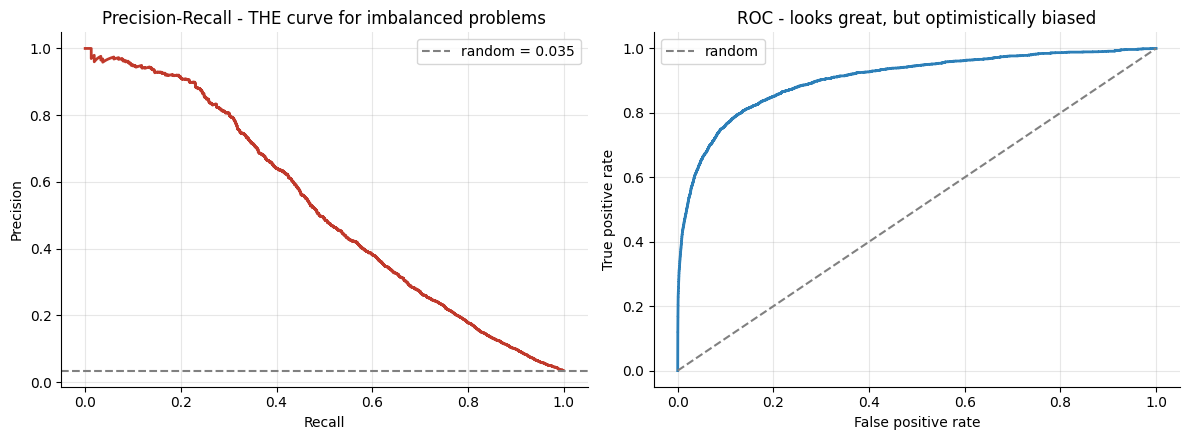

In [6]:
prec, rec, _ = precision_recall_curve(y_val, p_val)
fpr, tpr, _  = roc_curve(y_val, p_val)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
a1.plot(rec, prec, color=FRAUD_C, lw=2)
a1.axhline(base_rate, ls="--", c="grey", label=f"random = {base_rate:.3f}")
a1.set_xlabel("Recall"); a1.set_ylabel("Precision")
a1.set_title("Precision-Recall - THE curve for imbalanced problems"); a1.legend()

a2.plot(fpr, tpr, color=LEGIT_C, lw=2)
a2.plot([0,1],[0,1], ls="--", c="grey", label="random")
a2.set_xlabel("False positive rate"); a2.set_ylabel("True positive rate")
a2.set_title("ROC - looks great, but optimistically biased"); a2.legend()
plt.tight_layout(); plt.show()

### Why the ROC curve is misleading here

ROC-AUC ≈ 0.905 looks excellent. But it's **optimistically biased** under heavy
imbalance because it rewards ranking the easy 96.5% majority correctly.

**Tiny example:** a 5% false-positive rate sounds small. On 70,560 legitimate
transactions that's **3,528 false alarms** — swamping the 2,536 real frauds.

The PR curve tells the honest story, and it's the one we optimise.

---
## 4. ⚠️ The risk engine — and a real bug I caught

### The cost model

| Outcome | Cost |
|---|---|
| **False negative** (fraud let through) | **the transaction amount** — we refund the customer |
| **False positive** (good customer declined) | **~£15** — review time + friction |
| **True positive** | we recover ~90%; the remainder is still a loss |

**The key insight: the costs are asymmetric AND one of them varies.**

```
£10 transaction @ 60% fraud probability
   → expected saving £6, false-alarm cost £15      → DON'T BLOCK

£5,000 transaction @ 20% fraud probability
   → expected saving £1,000, false-alarm cost £15  → BLOCK
```

**A lower probability justifies blocking a larger amount** — which is why a
single global probability threshold is suboptimal, and why banks think in
**expected loss**.

### ⚠️ The bug: my first cost function was wrong

```python
cost = fraud_missed + false_positive_cost - recovered   # WRONG
```

It ran fine and produced:

```
cost-optimal : GBP  -66,541     <- NEGATIVE
NET SAVING   : GBP  463,455 (116.8% of fraud loss avoided)
```

**Both are physically impossible.** You cannot avoid more loss than exists, and
you cannot *make money* by declining transactions.

**Root cause — conceptual, not a typo:** catching fraud **avoids** a loss; it
does not **earn** revenue. Subtracting the recovered amount as income meant
every extra fraud caught pushed "cost" down without limit, so the optimiser
flagged more and more — landing at a **13.86% alert rate at 19.6% precision**,
below the project's own 20% precision floor.

**The fix:**

```python
cost = fraud_missed                    # full value, we refund it
     + fraud_caught × (1 − recovery)   # the part we could NOT recover
     + false_positives × review_cost
```

In [7]:
co = xgb["cost_optimal"]; dn = xgb["do_nothing_baseline"]; va = xgb["value_added"]

print("CORRECTED risk engine (validation):")
print(f"  do nothing     : GBP {dn['net_cost']:>12,.0f}   all fraud gets through")
print(f"  cost-optimal   : GBP {co['net_cost']:>12,.0f}   net loss after acting")
print(f"  NET SAVING     : GBP {va['net_saving']:>12,.0f}   "
      f"({va['pct_of_fraud_loss_avoided']:.1f}% of fraud loss avoided)")
print(f"  threshold {co['threshold']:.4f} | precision {co['precision']:.1%} "
      f"| recall {co['recall']:.1%} | alert rate {co['alert_rate']:.2%}")
print()
print("-" * 62)
print("BEFORE the fix: -66,541 net cost, 116.8% avoided,")
print("                13.86% alert rate, 19.6% precision  (impossible)")
print("AFTER  the fix: more conservative, and physically possible.")

CORRECTED risk engine (validation):
  do nothing     : GBP      396,914   all fraud gets through
  cost-optimal   : GBP      221,422   net loss after acting
  NET SAVING     : GBP      175,491   (44.2% of fraud loss avoided)
  threshold 0.4548 | precision 27.4% | recall 69.8% | alert rate 8.84%

--------------------------------------------------------------
BEFORE the fix: -66,541 net cost, 116.8% avoided,
                13.86% alert rate, 19.6% precision  (impossible)
AFTER  the fix: more conservative, and physically possible.


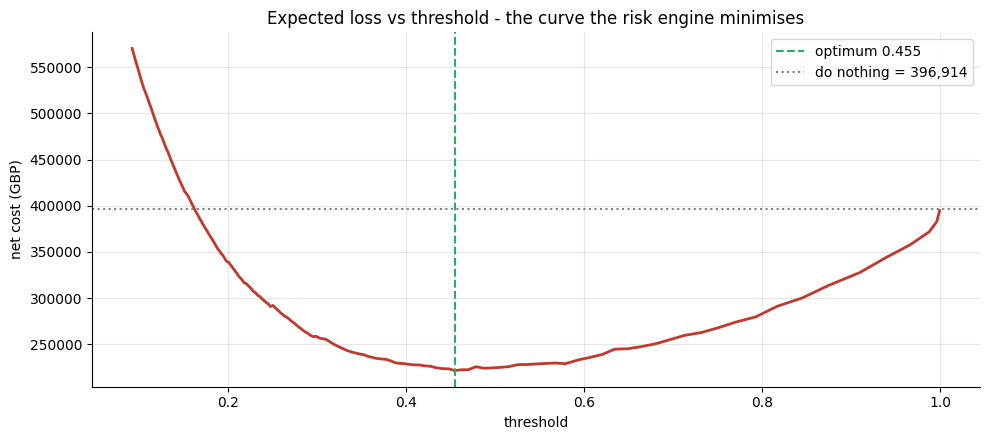

The curve never goes below zero. That invariant is now a test.


In [8]:
from risklens.models.evaluate import CostModel
cm = CostModel()
_, sweep = cm.optimal_threshold(y_val, p_val, amt_val)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(sweep["threshold"], sweep["net_cost"], color=FRAUD_C, lw=2)
best = sweep.loc[sweep["net_cost"].idxmin()]
ax.axvline(best["threshold"], ls="--", c=OK_C,
           label=f"optimum {best['threshold']:.3f}")
ax.axhline(dn["net_cost"], ls=":", c="grey",
           label=f"do nothing = {dn['net_cost']:,.0f}")
ax.set_xlabel("threshold"); ax.set_ylabel("net cost (GBP)")
ax.set_title("Expected loss vs threshold - the curve the risk engine minimises")
ax.legend(); plt.tight_layout(); plt.show()

print("The curve never goes below zero. That invariant is now a test.")

---
## 5. The final, honest test number

**Methodology:** the threshold was chosen on **validation** and applied
**unchanged** to **test**. Retuning on test would make the reported number
optimistically biased, and nothing could detect that afterwards.

**Test is opened once.**

In [9]:
t  = evaluation["test"]
tm = t["metrics"]; tc = t["confusion"]

print(f"  PR-AUC   {tm['pr_auc']:.4f}   ({tm['pr_auc_lift']:.1f}x random)")
print(f"  ROC-AUC  {tm['roc_auc']:.4f}")
print(f"  Brier    {tm['brier']:.5f}")
print()
print(f"  at the VALIDATION-chosen threshold {t['threshold_from_validation']:.4f}:")
print(f"    precision {tc['precision']:.1%} | recall {tc['recall']:.1%} "
      f"| alert rate {tc['alert_rate']:.2%}")
print(f"    caught {tc['tp']:,} | missed {tc['fn']:,} | false alarms {tc['fp']:,}")
print()
print(f"  do nothing     : GBP {t['do_nothing_cost']:>12,.0f}")
print(f"  with RiskLens  : GBP {t['cost']['net_cost']:>12,.0f}")
print(f"  NET SAVING     : GBP {t['net_saving']:>12,.0f}   "
      f"({t['pct_of_fraud_loss_avoided']:.1f}% of fraud loss avoided)")
print()
print(f"  generalisation gap (test - val PR-AUC): "
      f"{evaluation['generalisation_gap_pr_auc']:+.4f}")

  PR-AUC   0.4680   (13.1x random)
  ROC-AUC  0.8883
  Brier    0.05894

  at the VALIDATION-chosen threshold 0.4548:
    precision 25.2% | recall 65.0% | alert rate 9.20%
    caught 1,713 | missed 921 | false alarms 5,086

  do nothing     : GBP      395,802
  with RiskLens  : GBP      234,738
  NET SAVING     : GBP      161,063   (40.7% of fraud loss avoided)

  generalisation gap (test - val PR-AUC): -0.0553


### Reading the generalisation gap

Test PR-AUC is **slightly lower** than validation. **That is the healthy,
expected result**, and it's evidence the temporal split worked:

- The test period is *later in time*, so fraud patterns have drifted
- The threshold was tuned on validation, so it fits validation slightly better

A gap of **zero or positive** would be suspicious — it would suggest the split
leaked, or that we'd been peeking at test.

---
## 6. SHAP — what the model actually uses

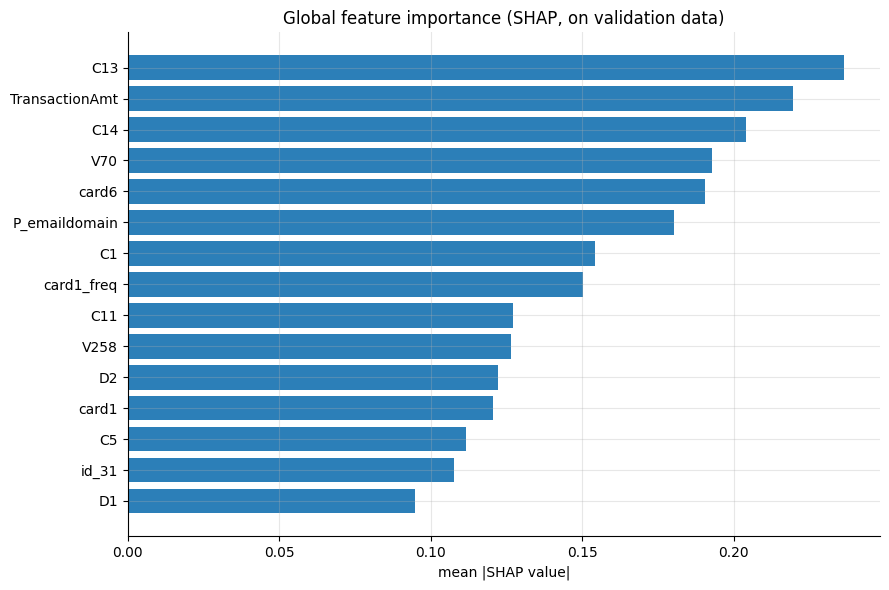

top feature: C13 holds 8.4% of total SHAP magnitude


In [10]:
imp = pd.read_csv(cfg.reports_dir / "stage07_shap_importance.csv")
top = imp.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["feature"], top["mean_abs_shap"], color=LEGIT_C)
ax.set_xlabel("mean |SHAP value|")
ax.set_title("Global feature importance (SHAP, on validation data)")
plt.tight_layout(); plt.show()

share = imp["mean_abs_shap"] / imp["mean_abs_shap"].sum()
print(f"top feature: {imp.iloc[0]['feature']} holds {share.iloc[0]:.1%} "
      "of total SHAP magnitude")

### The leakage audit

**Heuristic:** if any ONE feature holds more than **35%** of total SHAP
magnitude, treat it as a leakage suspect until proven otherwise.

**The reasoning:** Stage 2 found *nothing* with an effect size above 0.24. Real
fraud signal is **diffuse**. A single dominant feature usually means it encodes
the answer, the split, or the time period.

**Our verdict: healthy** — importance is spread across many features, which is
what genuine fraud signal looks like.

> **This is the fastest leakage-detection tool in the project.** Had I
> accidentally left `TransactionDT` in the features, SHAP would show it
> dominating, because the model would have discovered `DT > 13,000,000 → test`.

**One caution:** SHAP explains the **model**, not the world. It tells you what
the model *used*, not what *causes* fraud. Stage 2's confounder finding is the
perfect illustration — identity-present predicts fraud, but the *channel*
causes it.

### Why mean **absolute** SHAP

A feature that pushes risk **+0.5** for half the transactions and **−0.5** for
the other half would average to **zero** signed — and look useless. Absolute
values give **0.5**, correctly identifying it as important. We want magnitude
of influence, not net direction.

---
# Summary

| # | Result | Meaning |
|---|---|---|
| 1 | Baseline PR-AUC **0.3137** (9.0× random) | The bar to beat |
| 2 | XGBoost PR-AUC **0.5233** (15.1× random) | +67% relative — complexity justified |
| 3 | Brier **0.0557** vs 0.1370 | ~2.5× better calibrated |
| 4 | At 0.5% alert budget: **94.3% precision** | Nearly every alert is real fraud |
| 5 | ⚠️ First cost model: **116.8% avoided** | Impossible → found a conceptual bug |
| 6 | Corrected: **44.2% of fraud loss avoided** | Physically possible, and now tested |
| 7 | **Test PR-AUC 0.4680**, 40.7% avoided | The honest number, threshold not retuned |
| 8 | Generalisation gap **−0.055** | Small and negative — the split held |
| 9 | Leakage audit **healthy** | Importance spread, as real fraud signal is |

## The lesson worth remembering

> **A result that is too good is a bug report, not a success.**

The 116.8% figure and the leakage audit are the same instinct applied twice:
suspicion should scale with how impressive your numbers look.

## What's next

**Stages 8–9:** case narratives from SHAP reason codes, semantic search over
them, RAG over the fraud policy corpus, and an investigation copilot whose
tools *are* the components above.

**Stage 10:** a FastAPI scoring service and a Streamlit analyst console,
both loading the exact training artefacts to prevent training/serving skew.